In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from scipy.ndimage import uniform_filter1d
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import scipy.signal as sp
from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup
from tqdm.notebook import tqdm

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [3]:
def get_patch_fs_metadata(metadata_file, cell_num):
    
    metafile = pd.read_excel(metadata_file, sheet_name='Sheet1')
    #get index for cell
    cells = metafile['Cell']
    index_cell = cells[cells == "c"+str(cell_num)].index[0]
    
    #get path fs for cell
    
    patch_fs = metafile['Patch Samp. Freq. (Hz)'][index_cell]
    
    return patch_fs
    

In [4]:

patch_fs_c42 = 50023.8817047623



In [5]:
patch_c42 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'
#get cell number 
cell_num = 'c42'


#get patch data 
patch_filt_c42 = np.load(patch_c42)
patch_c42_one_ms = float(patch_fs_c42  / 1000)
patch_times_c42 = np.arange(0, np.shape(patch_filt_c42 )[0]) / patch_c42_one_ms # in ms instead of sec


patch_channel = patch_filt_c42

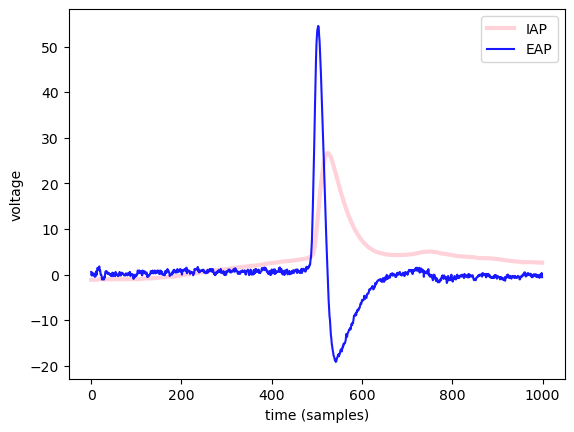

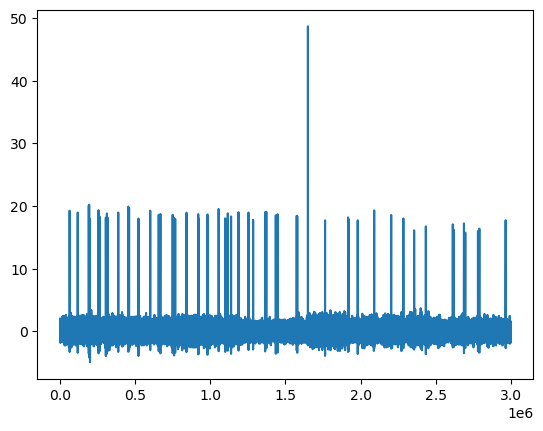

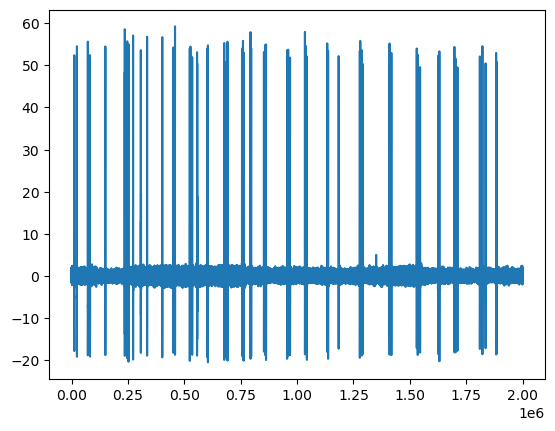

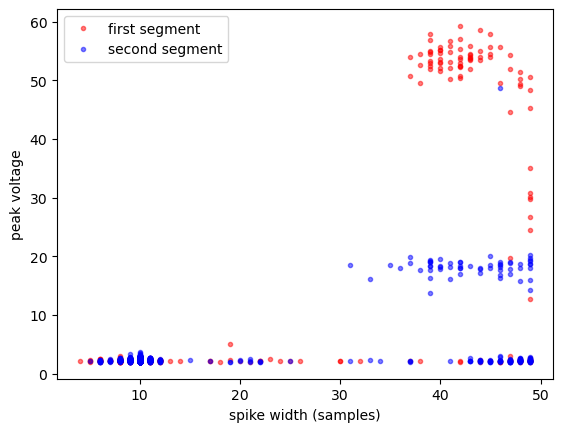

In [6]:


patch_fs = patch_fs_c42

# smooth the iap a bit, otherwise it's WAY more noisy
patch_filt = uniform_filter1d(patch_channel, size=10)

iap2eap = np.diff(patch_filt)
iap2eap = iap2eap * 50 # this is arbitrary, just to scale it better to the iap

# grab semi-random long segments near the beginning and end
first_segment = iap2eap[:2000000]
last_segment = iap2eap[37521059:40521059]

# show that the pseudo-eap works
plt.plot(patch_filt[23000:24000], 'pink', linewidth=3, alpha=0.7, label='IAP')
plt.plot(first_segment[23000:24000], 'b', alpha = 0.9, label='EAP')
plt.xlabel('time (samples)')
plt.ylabel('voltage')
plt.legend()
plt.show()

plt.plot(iap2eap[37521059:40521059])
plt.show()
plt.plot(iap2eap[:2000000])
plt.show()
# function to get peaks, then get the minimum after the peak to get peak-trough duration, which is a proxy for spike-width
def find_next_minima(iap, eap, peakheight, minwin):
    peaks, peak_height = find_peaks(iap, height=peakheight, distance=minwin)
    
    # Using list comprehension to find the index of the next minimum for each peak
    next_minima_indices = [
        peak + np.argmin(eap[peak:peak + minwin]) if np.any(eap[peak:] < eap[peak]) else None
        for peak in peaks
    ]
    
    peak_height = peak_height['peak_heights']
    return peaks, next_minima_indices, peak_height

peaks_first, troughs_first, amp_first = find_next_minima(first_segment, first_segment, 2, 50)
peaks_last, troughs_last, amp_last = find_next_minima(last_segment, last_segment, 2, 50)

# plot the 2d feature space of peak voltage vs. spike width
plt.plot(troughs_first-peaks_first, amp_first, 'r.', alpha=0.5, label='first segment')
plt.plot(troughs_last-peaks_last, amp_last, 'b.', alpha=0.5, label='second segment')
plt.xlabel('spike width (samples)')
plt.ylabel('peak voltage')
plt.legend()
plt.show()

40521059

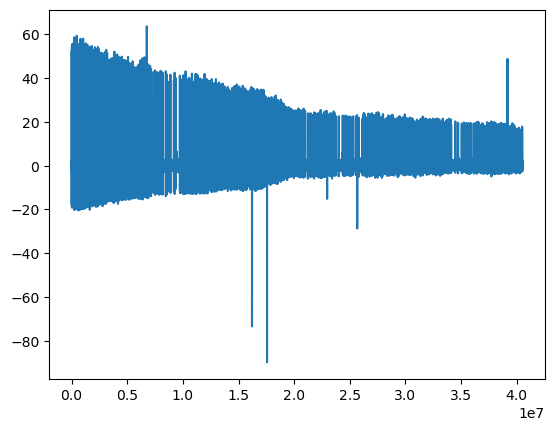

In [7]:
plt.plot(iap2eap)
len(iap2eap)

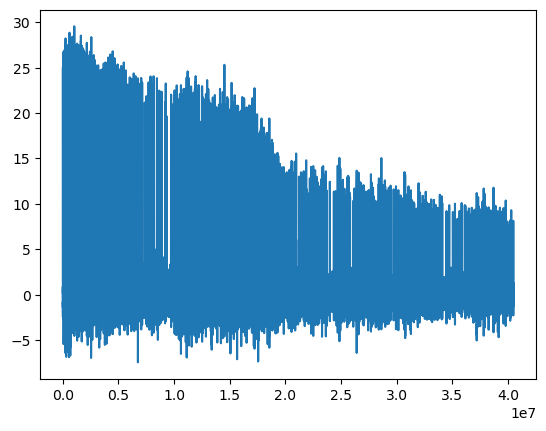

In [8]:
plt.plot(patch_filt)

### Check how the inferred EAPs compare to the actual EAPs

In [9]:
#load npx data
npx_file_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'
npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/c42npx_filt.npy'
npx_fs = 30000 # sampling rate
npx_one_ms = float(npx_fs / 1000)
npx_channels = 384
npx_patch_channel = 109

In [10]:
# open and load the data
npx_filt = np.load(npx_path)
npx_times_c42 = np.arange(0, np.shape(npx_filt)[0]) / npx_one_ms # in ms instead of sec"""

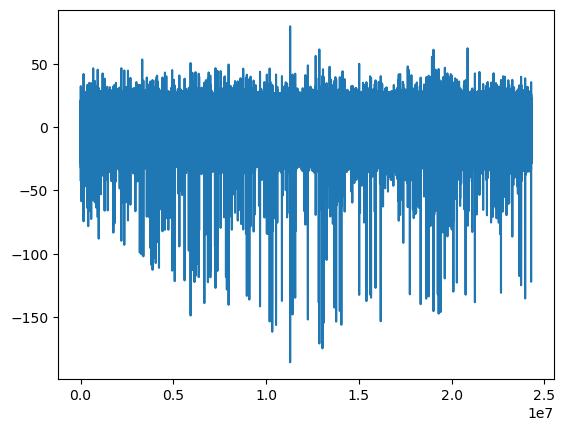

In [11]:
plt.plot(npx_filt)

In [12]:
#Run spikeparam on real EAPs 
sp_ex = Spike(thresh_amp=31.5, window_length=(5., 5.), smooth_frac=.01)

#sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
 #      param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))

sp_ex.fit(npx_filt, npx_fs, n_jobs=-1, progress=tqdm)

Fatal Python error: config_get_locale_encoding: failed to get the locale encoding: nl_langinfo(CODESET) failed
Python runtime state: preinitialized

Fatal Python error: config_get_locale_encoding: failed to get the locale encoding: nl_langinfo(CODESET) failed
Python runtime state: preinitialized
Fatal Python error: config_get_locale_encoding: 
failed to get the locale encoding: nl_langinfo(CODESET) failed
Python runtime state: preinitialized

Fatal Python error: config_get_locale_encoding: failed to get the locale encoding: nl_langinfo(CODESET) failed
Python runtime state: preinitialized

/Users/blancamartin/opt/anaconda3/lib/python3.9/multiprocessing/resource_tracker.py:96: UserWarning: resource_tracker: process died unexpectedly, relaunching.  Some resources might leak.
  warnings.warn('resource_tracker: process died unexpectedly, '
Fatal Python error: config_get_locale_encoding: failed to get the locale encoding: nl_langinfo(CODESET) failed
Python runtime state: preinitialized

Fata

Spike:   0%|          | 0/326 [00:00<?, ?it/s]

Fatal Python error: config_get_locale_encoding: failed to get the locale encoding: nl_langinfo(CODESET) failed
Python runtime state: preinitialized

Fatal Python error: config_get_locale_encoding: failed to get the locale encoding: nl_langinfo(CODESET) failed
Python runtime state: preinitialized

Fatal Python error: config_get_locale_encoding: failed to get the locale encoding: nl_langinfo(CODESET) failed
Python runtime state: preinitialized

Fatal Python error: config_get_locale_encoding: failed to get the locale encoding: nl_langinfo(CODESET) failed
Python runtime state: preinitialized

Fatal Python error: config_get_locale_encoding: failed to get the locale encoding: nl_langinfo(CODESET) failed
Python runtime state: preinitialized

Fatal Python error: config_get_locale_encoding: failed to get the locale encoding: nl_langinfo(CODESET) failed
Python runtime state: preinitialized

Fatal Python error: config_get_locale_encoding: failed to get the locale encoding: nl_langinfo(CODESET) fa

KeyboardInterrupt: 

In [ ]:
sp_ex.plot()

In [ ]:
#Downsample inferred EAPs to match real EAP sampling rate
iap2eap = sp.resample(iap2eap, int((len(iap2eap)/patch_fs)*npx_fs))

In [ ]:
#Run spikeparam on inferred EAPs 

sp_ex_inf = Spike(thresh_amp=41.5, window_length=(5., 5.), smooth_frac=.01)

#sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
 #      param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))

sp_ex_inf.fit(iap2eap, patch_fs, n_jobs=-1, progress=tqdm)

In [ ]:
sp_ex_inf.plot()